In [1]:
!pip install sentence-transformers seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached sentence_transformers-5.3.0-py3-none-any.whl.metadata (16 kB)
  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.7.2-py3-none-any.whl.metadata (13 kB)
  Using cached torch-2.10.0-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached numpy-2.4.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.2.28-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


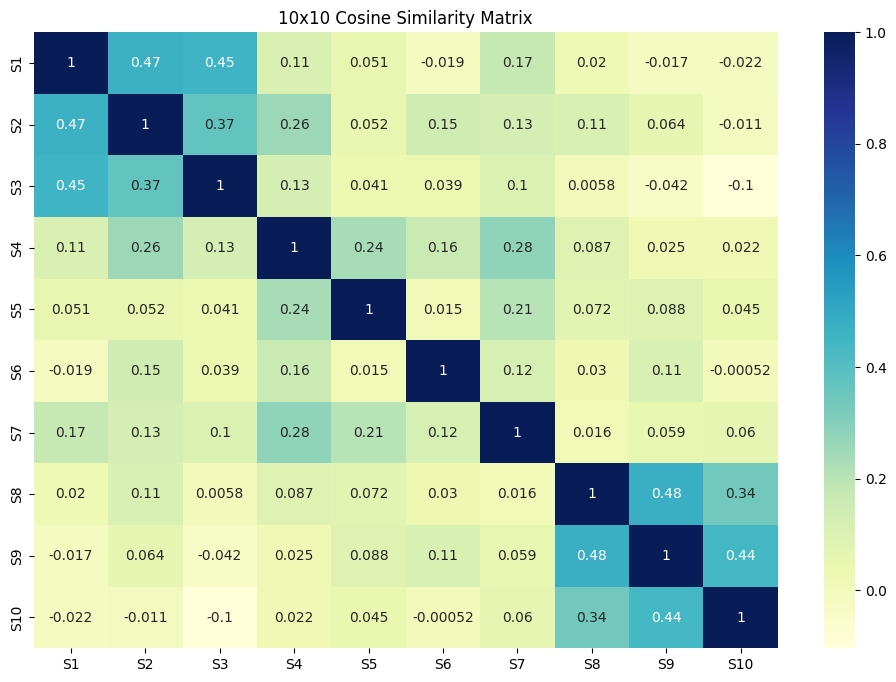


Query: 'The bowler took three wickets in one over'
--------------------------------------------------
Similar Sentence: Fast bowlers often rely on swing and seam movement to take wickets.
Similarity Score: 0.5709

Similar Sentence: The opening batsman hit a magnificent century in the final match.
Similarity Score: 0.5480



In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# 1. Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Define 10 sentences across 3 topics (Cricket, Cooking, Cybersecurity)
sentences = [
    # Cricket
    "The opening batsman hit a magnificent century in the final match.",
    "Fast bowlers often rely on swing and seam movement to take wickets.",
    "The fielding side celebrated a spectacular catch at the boundary line.",

    # Cooking
    "Slow-cooking the beef ensures the meat remains tender and flavorful.",
    "A pinch of saffron can drastically change the aroma of the risotto.",
    "Baking bread requires a precise balance of yeast, flour, and water.",
    "The chef used a sharp knife to julienne the vegetables for the stir-fry.",

    # Cybersecurity
    "Multi-factor authentication adds an essential layer of security to accounts.",
    "Phishing attacks often use deceptive emails to steal user credentials.",
    "Encrypting sensitive data prevents unauthorized access during a breach."
]

# 3. Generate Embeddings
embeddings = model.encode(sentences, convert_to_tensor=True)

# 4. Compute 10x10 Cosine Similarity Matrix
cosine_scores = util.cos_sim(embeddings, embeddings).numpy()

# 5. Display Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cosine_scores, annot=True, cmap='YlGnBu',
            xticklabels=[f"S{i+1}" for i in range(10)],
            yticklabels=[f"S{i+1}" for i in range(10)])
plt.title("10x10 Cosine Similarity Matrix")
plt.show()

# 6. Query Similarity Search
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarities for the query
query_scores = util.cos_sim(query_embedding, embeddings)[0]

# Find top 2 most similar
top_results = np.argsort(-query_scores)[:2]

print(f"\nQuery: '{query}'")
print("-" * 50)
for idx in top_results:
    print(f"Similar Sentence: {sentences[idx]}")
    print(f"Similarity Score: {query_scores[idx]:.4f}\n")